## Introduction

This project analyzes 2024 U.S. flight data to identify which drivers contribute most to delays across U.S. airlines. The analysis focuses on delay causes, time of day patterns, and differences between carriers to better understand both the frequency and severity of delays.

The goal is to uncover key operational insights that explain why delays occur and how they compound throughout the day.

In [20]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.analysis import *


    
df = pd.read_csv('../data/flight_data_2024.csv')

# Use the sample dataset below for faster testing during development
# df = pd.read_csv('../data/flight_data_2024_sample.csv') 

# Initial data exploration
print(df.info())
print(df.describe())
print(df.head())

C:\Users\13475\AppData\Local\Temp\ipykernel_14340\975701926.py:9: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/flight_data_2024.csv')


<class 'pandas.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              str    
 5   op_unique_carrier    str    
 6   op_carrier_fl_num    float64
 7   origin               str    
 8   origin_city_name     str    
 9   origin_state_nm      str    
 10  dest                 str    
 11  dest_city_name       str    
 12  dest_state_nm        str    
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24  cancellat

In [21]:
# Data cleaning and feature engineering from src/analysis.py
df = clean_data(df)
df = add_delay_indicator(df)
df = add_dep_hour(df)


In [22]:
# Compute all analytics and unpack into variables
analytics = compute_all_analytics(df)
avg_delay_by_dep_hour = analytics['avg_delay_by_dep_hour']
avg_arr_delay_by_carrier = analytics['avg_arr_delay_by_carrier']
delay_rate_pct_by_carrier = analytics['delay_rate_pct_by_carrier']
delay_totals_by_delay_type = analytics['delay_totals_by_delay_type']
delay_totals_by_type_per_carrier = analytics['delay_totals_by_type_per_carrier']
combined = analytics['combined_metrics']

In [23]:
# Basic statistics/ sanity checks
print("Total Flights:", df.shape[0])
print("Avg Arrival Delay:", df['arr_delay'].mean())



Total Flights: 7079081
Avg Arrival Delay: 6.9841232216441655


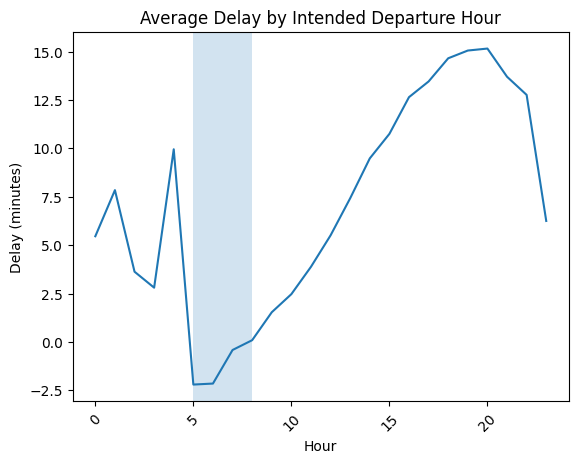

In [24]:
# Average delay by intended departure hour (HH)

avg_delay_by_dep_hour.plot()
plt.title("Average Delay by Intended Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.axvspan(5, 8, alpha=0.2)  # highlight best departure timewindow
plt.savefig('../visuals/avg_delays_by_dep_hour.png', bbox_inches='tight')
plt.show()

### Insight

Flights departing between 5am and 8am display the lowest average delays, while delays stedily increase throughout the day. This pattern likely represents a trickle down effect where later flights are impacted by earlier delays. This suggest that earlier scheduling is more reliable and emphasizes the importance of operational efficiency in minimizing delays.

In [25]:
# Departure hours with lowest average delay
avg_delay_by_dep_hour.sort_values(ascending=True).head(5)

# Departure hours with highest average delay
# avg_delay_by_dep_hour.sort_values(ascending=False).head(5)

dep_hour
5   -2.202001
6   -2.150205
7   -0.416155
8    0.090957
9    1.534567
Name: arr_delay, dtype: float64

{'AA': 'American Airlines', 'F9': 'Frontier Airlines', 'B6': 'JetBlue Airways', 'OH': 'PSA Airlines', 'G4': 'Allegiant Air', 'NK': 'Spirit Airlines', 'OO': 'SkyWest Airlines', 'MQ': 'Envoy Air', 'UA': 'United Airlines', 'WN': 'Southwest Airlines', 'AS': 'Alaska Airlines', 'HA': 'Hawaiian Airlines', 'DL': 'Delta Air Lines', '9E': 'Endeavor Air', 'YX': 'Republic Airways'}


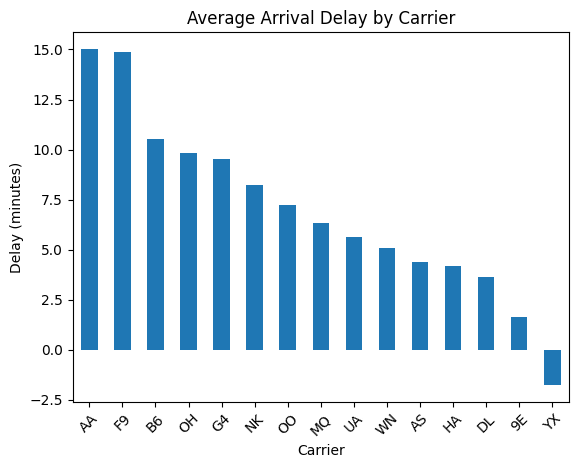

In [26]:
# Carrier Key
print(carrier_code_map)

# Average delays by carrier (minutes)
avg_arr_delay_by_carrier.sort_values(ascending=False).plot(kind='bar')
plt.title("Average Arrival Delay by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.savefig('../visuals/avg_delay_by_carrier.png', bbox_inches='tight')
plt.show()


### Insight 

American Airlines exhibits the highest average delay, while Republic Airways has the lowest, highlighting differences in operational efficiency and scheduling reliability across carriers.

This suggests that delays are not uniform across the industry and may be driven by airline-specific operational practices. 

{'AA': 'American Airlines', 'F9': 'Frontier Airlines', 'B6': 'JetBlue Airways', 'OH': 'PSA Airlines', 'G4': 'Allegiant Air', 'NK': 'Spirit Airlines', 'OO': 'SkyWest Airlines', 'MQ': 'Envoy Air', 'UA': 'United Airlines', 'WN': 'Southwest Airlines', 'AS': 'Alaska Airlines', 'HA': 'Hawaiian Airlines', 'DL': 'Delta Air Lines', '9E': 'Endeavor Air', 'YX': 'Republic Airways'}


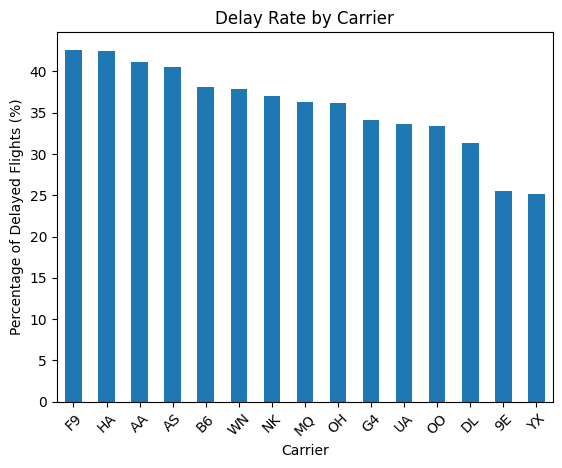

In [27]:
# Carrier key
print(carrier_code_map)

# Delay rate by carrier (%)

delay_rate_pct_by_carrier.sort_values(ascending=False).plot(kind='bar')
plt.title("Delay Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Percentage of Delayed Flights (%)")
plt.xticks(rotation=45)
plt.savefig('../visuals/delay_rate_by_carrier.png', bbox_inches='tight')
plt.show()

### Insight 

American Airlines ranks among the top three airlines in delay rate, alongside Frontier Airlines and Hawaiian Airlines, each exceeding a 40% likelihood of delay. In contrast, Republic Airways maintains a substantially lower delay rate of approximately 25%.

This variation reinforces the idea that operational efficiency (particularly in scheduling and aircraft turnaround) differs significantly across carriers and is a key factor of delay outcomes.

In [28]:
# Top 5 Best carriers by delay rate
delay_rate_pct_by_carrier.sort_values(ascending=True).rename(index=carrier_code_map).head(5)

op_unique_carrier
Republic Airways    25.144544
Endeavor Air        25.489020
Delta Air Lines     31.270103
SkyWest Airlines    33.333557
United Airlines     33.564424
Name: is_delayed, dtype: float64

In [29]:
# Top 5 worst carriers by delay rate
delay_rate_pct_by_carrier.sort_values(ascending=False).rename(index=carrier_code_map).head(5)

op_unique_carrier
Frontier Airlines    42.602960
Hawaiian Airlines    42.464026
American Airlines    41.118006
Alaska Airlines      40.494429
JetBlue Airways      38.101481
Name: is_delayed, dtype: float64

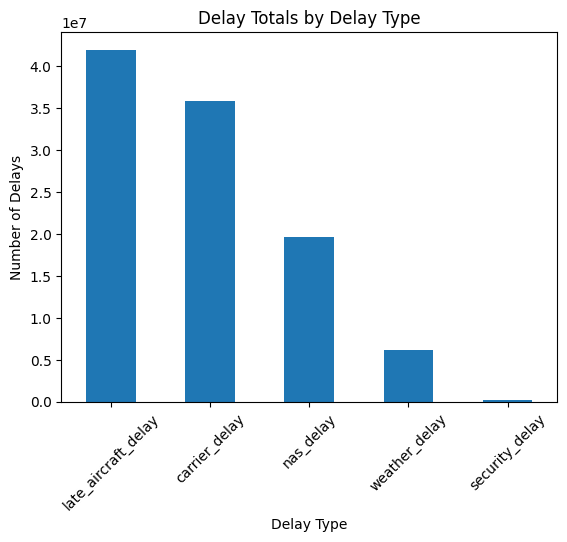

In [30]:
# Calculate total delay minutes for each type of delay

delay_totals_by_delay_type.sort_values(ascending=False).plot(kind='bar')
plt.title('Delay Totals by Delay Type')
plt.xlabel('Delay Type')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45)
plt.savefig('../visuals/delay_totals_by_delay_type', bbox_inches='tight' )
plt.show()

### Inght 

Late aircraft delays are the largest contributor to total delay minutes, followed by Carrier-related and NAS delays. This also suggests that internal airline operations, rather than external factors like weather, are the primary factors of delays. Improving turnaround efficiency and schedule planning could help reduce delays for underperforming carriers.

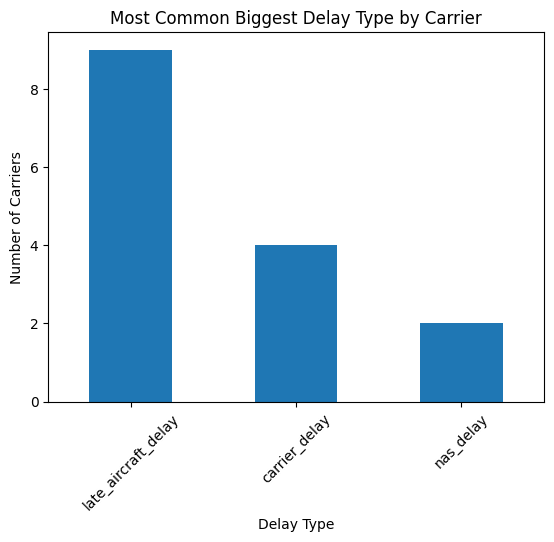

In [31]:
 # Delay types that are the biggest for most carriers 

delay_totals_by_type_per_carrier.idxmax(axis=1).value_counts().plot(kind='bar')
plt.title('Most Common Biggest Delay Type by Carrier')
plt.xlabel('Delay Type')
plt.ylabel('Number of Carriers')
plt.xticks(rotation=45) 
plt.savefig('../visuals/most_common_biggest_delay_type_by_carrier.png', bbox_inches='tight')
plt.show()

### Insight

Late aircraft delays are the most common source of total delay minutes accross carriers, suggesting that operational delays frequently originate from earlier flights. This reinforces the presence of a cascading effect, where delays compound over time and impact subsequent departures.

In [32]:
# Biggest delay type for each carrier
delay_totals_by_type_per_carrier.idxmax(axis=1) 

op_unique_carrier
Endeavor Air          late_aircraft_delay
American Airlines     late_aircraft_delay
Alaska Airlines       late_aircraft_delay
JetBlue Airways             carrier_delay
Delta Air Lines             carrier_delay
Frontier Airlines     late_aircraft_delay
Allegiant Air         late_aircraft_delay
Hawaiian Airlines           carrier_delay
Envoy Air             late_aircraft_delay
Spirit Airlines                 nas_delay
PSA Airlines          late_aircraft_delay
SkyWest Airlines            carrier_delay
United Airlines       late_aircraft_delay
Southwest Airlines    late_aircraft_delay
Republic Airways                nas_delay
dtype: str

In [33]:
# Carrier with the biggest delay for each delay type
delay_totals_by_type_per_carrier.idxmax() 

carrier_delay           American Airlines
weather_delay            SkyWest Airlines
nas_delay               American Airlines
security_delay         Southwest Airlines
late_aircraft_delay     American Airlines
dtype: str

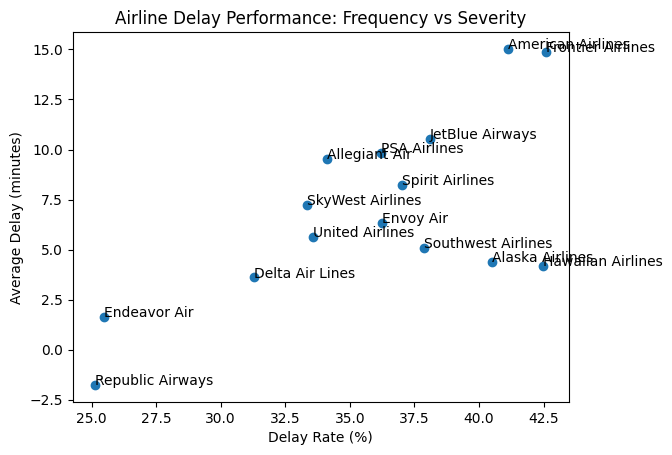

In [34]:
plt.scatter(combined['delay_rate_pct'], combined['avg_arr_delay_min'])

for airline in combined.index:
    plt.text(
        combined.loc[airline, 'delay_rate_pct'],
        combined.loc[airline, 'avg_arr_delay_min'],
        airline
    )

plt.title("Airline Delay Performance: Frequency vs Severity")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Average Delay (minutes)")
plt.savefig('../visuals/delay_rate_vs_avg_delay.png', bbox_inches='tight')  
plt.show()

### Insight 

American Airlines and Fontair Airlines, exhibit both high delay frequency and severity, indicating systemic operational inefficiencies. In contrast, Republic airways demonstrates more consistent and reliable performance.

There is a distinct liniar corrilation between delay frequency and duration sugesting that carrier operation efficancy is the common factor.

## Conclusion

This analysis examined flight delay patterns across U.S. airlines to identify the primary drivers influencing delays and how they vary by time and carrier. Analysis of time of day trends, delay cause breakdowns, and airline efficiency comparisons all support a consistent pattern: operational drivers primarily impact delays which then compound throughout the day.

Late aircraft delays were the most significant contributor to total delay minutes, reinforcing the presence of a compounding effect in which early disruptions impact subsequent flights. This pattern is further supported by time based analysis, which shows that early morning departures experience the lowest delays, while delays increase steadily later in the day.

Airline efficiency comparisons reveal meaningful differences in performance. Some carriers exhibit both higher delay frequency and severity, while others maintain more consistent timely operations. This suggests that operational efficiency, scheduling practices, and turnaround management play a critical role in delay outcomes.

Overall, the findings indicate that improving internal airline operations, particularly aircraft turnaround and schedule management, offers the greatest opportunity to reduce delays. While external factors such as weather contribute to disruptions, the primary factors of delays are within operational control, making them key targets for performance improvement.

Future work could extend this analysis by incorporating predictive modeling to forecast delays or by developing interactive dashboards to support realtime decision making.


In [ ]:
# save cleaned data for dashboard integration

# df.to_csv('../dashboard_data/flight_data_2024_cleaned.csv', index=False)
# avg_delay_by_dep_hour.to_csv('../dashboard_data/avg_delay_by_dep_hour.csv', index=True)
# avg_arr_delay_by_carrier.to_csv('../dashboard_data/avg_arr_delay_by_carrier.csv', index=True)
# delay_rate_pct_by_carrier.to_csv('../dashboard_data/delay_rate_pct_by_carrier.csv', index=True)
# delay_totals_by_delay_type.to_csv('../dashboard_data/delay_totals_by_delay_type.csv', index=True)
# delay_totals_by_type_per_carrier.to_csv('../dashboard_data/delay_totals_by_type_per_carrier.csv', index=True)
# combined.to_csv('../dashboard_data/combined_metrics.csv', index=True)
